In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load MNIST automatically
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [ ]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [ ]:
# Normalize pixel values from 0-255 to 0-1
train_data = x_train.astype("float32") / 255.0
test_data = x_test.astype("float32") / 255.0


In [ ]:
# Reshape each 28x28 image into a 784-dimensional vector
train_data = train_data.reshape(-1, 784)
test_data = test_data.reshape(-1, 784)

reshaping the data into 1d vector

creating the autoencoder

In [ ]:
input_layer = tf.keras.Input(shape=(784,))

# creating the encoder
encoded = tf.keras.layers.Dense(128, activation="relu")(input_layer)
encoded = tf.keras.layers.Dense(64, activation="relu")(encoded)
latent = tf.keras.layers.Dense(32, activation="relu")(encoded)

# creating the decoder
decoded = tf.keras.layers.Dense(64, activation="relu")(latent)
decoded = tf.keras.layers.Dense(128, activation="relu")(decoded)
output_layer = tf.keras.layers.Dense(784, activation="sigmoid")(decoded)

autoencoder = tf.keras.Model(input_layer, output_layer)

optimizing the weight of the autoencoder

In [ ]:
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

In [ ]:
history = autoencoder.fit(
    train_data,
    train_data,
    epochs=10,
    batch_size=256,
    validation_data=(test_data, test_data)
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0641 - val_loss: 0.0373
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0316 - val_loss: 0.0270
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0246 - val_loss: 0.0219
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0209 - val_loss: 0.0192
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0189 - val_loss: 0.0178
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0174 - val_loss: 0.0163
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0163 - val_loss: 0.0155
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0153 - val_loss: 0.0144
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0144 - val_loss: 0.0140
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0138 - val_loss: 0.0133


In [ ]:
reconstructed = autoencoder.predict(test_data)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


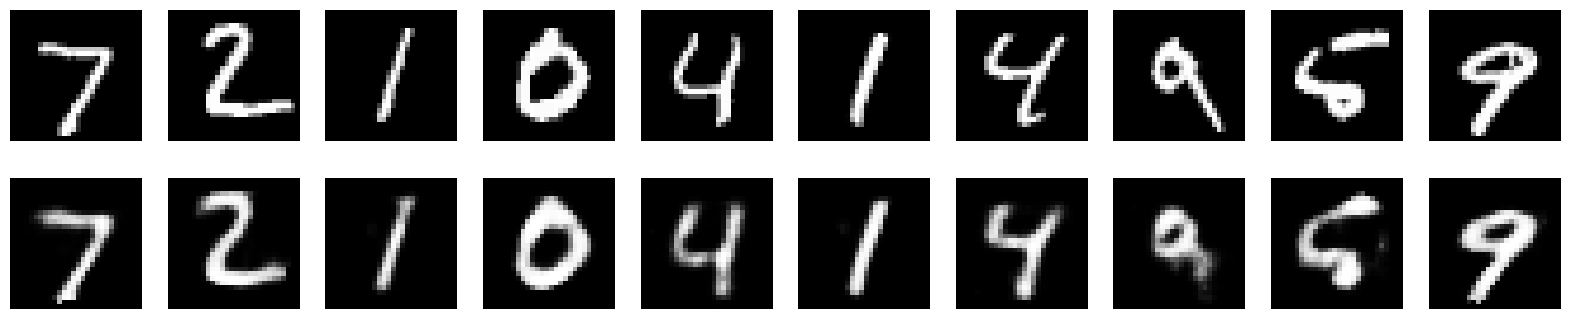

In [ ]:
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    plt.subplot(2, n, i + 1)
    plt.imshow(test_data[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.show()